# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [24]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
from skimage import data


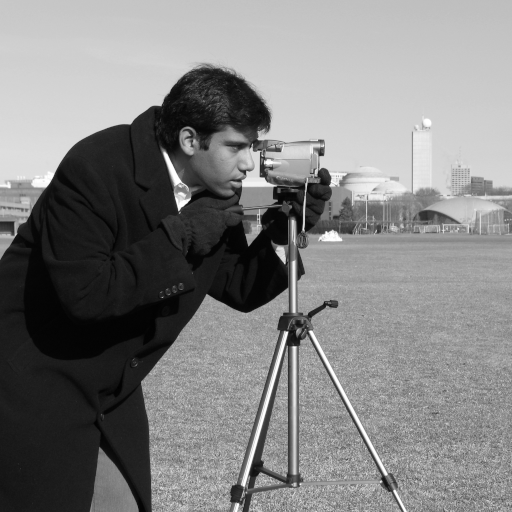

In [25]:
# ── Load image ────────────────────────────────────
img = Image.fromarray(data.camera())
display(img)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [67]:
# Get the size of the image
img.size
# scaling factors
scale_x = 2
scale_y = 2

In [32]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method

scaled_image1 = img.resize((img.width * scale_x, img.height * scale_y), Image.Resampling.LANCZOS)

In [37]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_image1.save("task1_1_scaled.jpg")
print("Original size:", img.size)
print("Scaled size:", scaled_image1.size)


Original size: (512, 512)
Scaled size: (1024, 1024)


#display two images

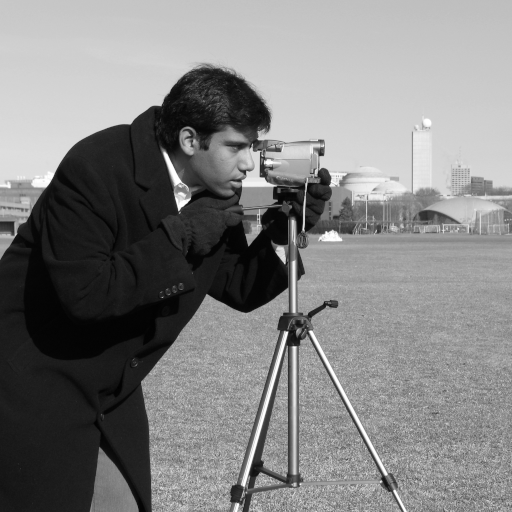

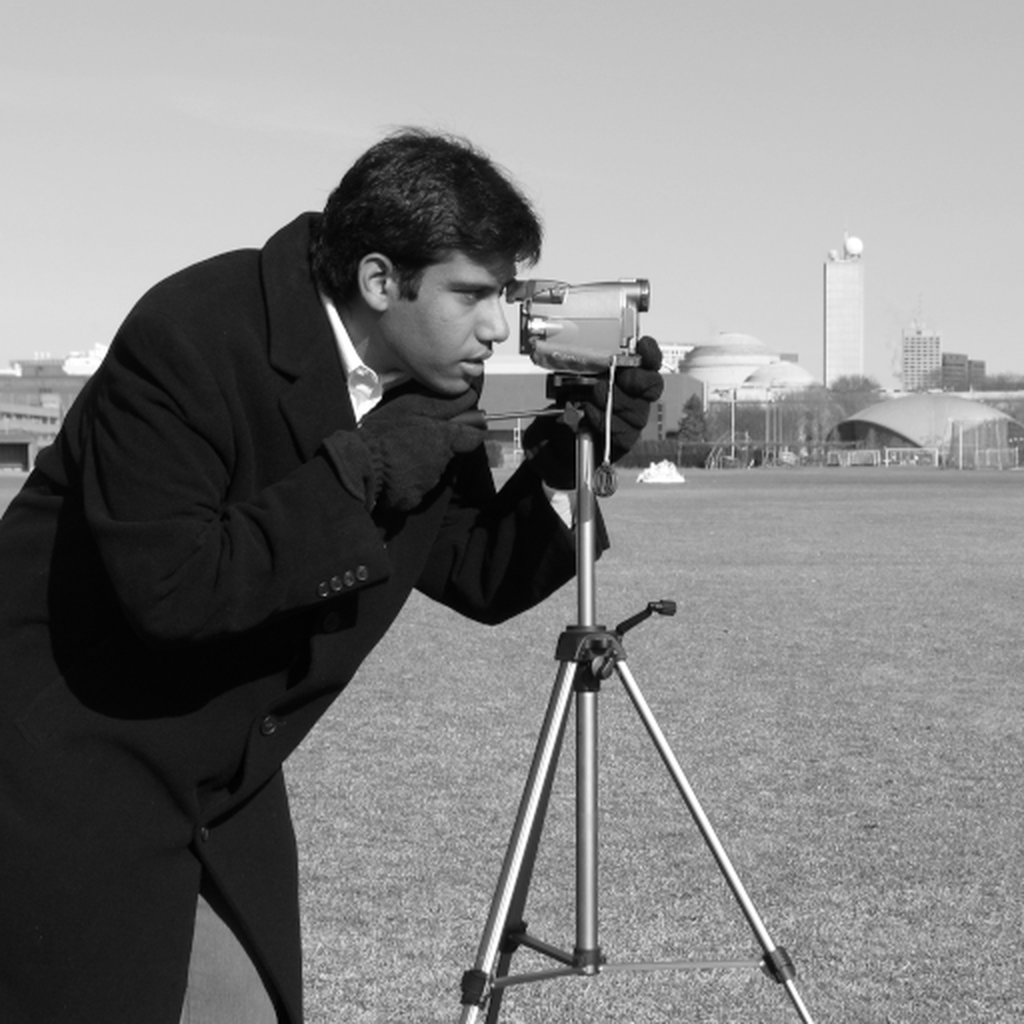

In [35]:
display(img)
display(scaled_image1)

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [42]:
scale_x = 2
scale_y = 1

In [43]:
scaled_image2 = img.resize((img.width * scale_x, img.height * scale_y), Image.Resampling.LANCZOS)

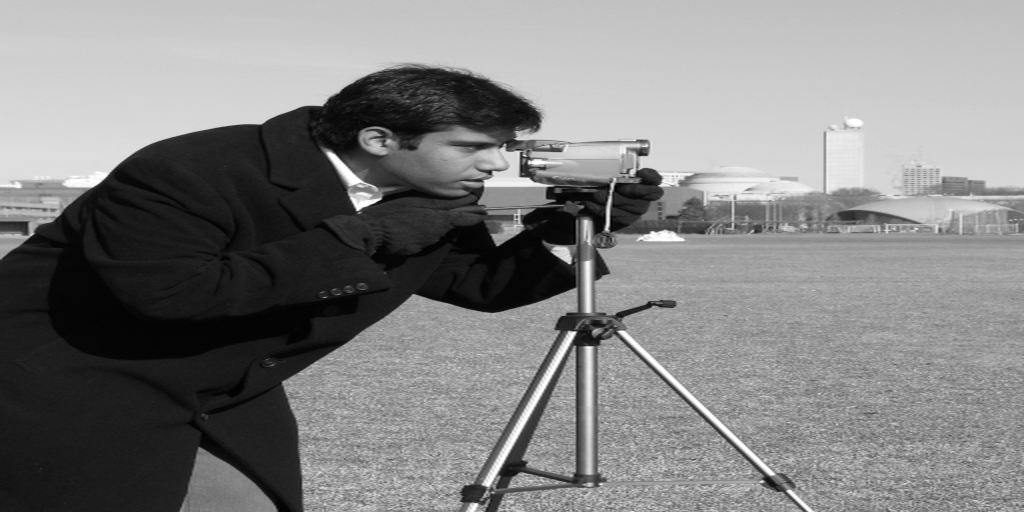

In [44]:
display(scaled_image2)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [50]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_image = img.rotate(120, expand=True)

# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_image.save("task1_2_rotated.jpg")
print("Original size:", img.size)
print("Rotated image size: ", rotated_image.size)


Original size: (512, 512)
Rotated image size:  (700, 700)


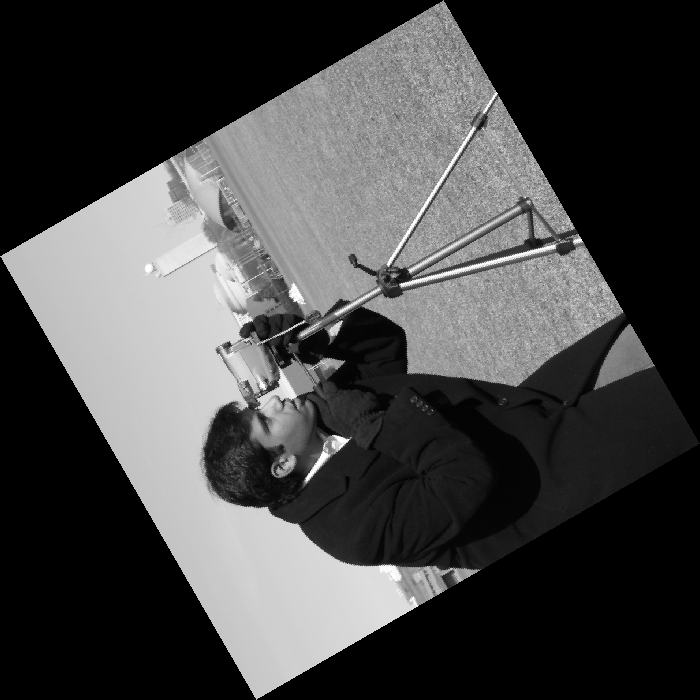

In [51]:
#display the rotated image
display(rotated_image)

### 3. Shear

In [62]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size
print("image dimensions:", width, "×", height)

image dimensions: 512 × 512


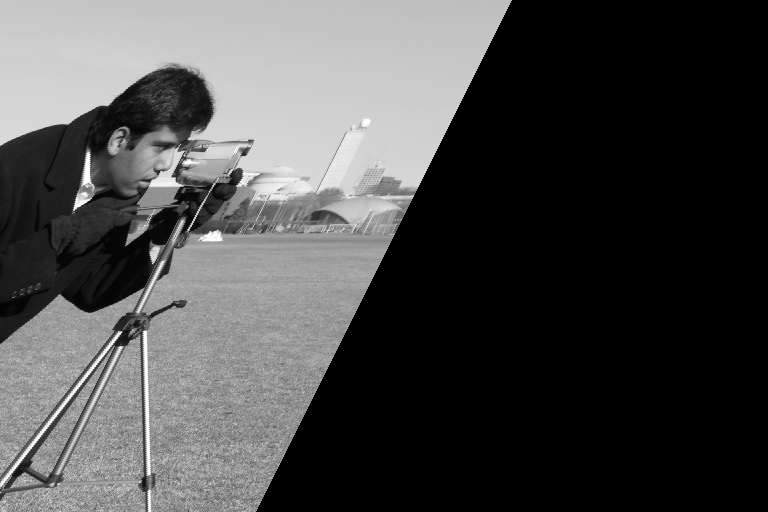

In [71]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_x = 0.5
shear_y = 0

#sheared_img = img.transform((width+shear_x*height, height), Image.Transform.AFFINE, (1, shear_x, 0, shear_y, 1, 0))
#but to avoid non integer size, we use int() and abs() to ensure the new size is valid
#and this is for compute new size, since that after shearing, the width of the image will change, "width" coz it's upon x-axis

new_size = (int(width + abs(shear_x) * height), height)
sheared_img = img.transform(new_size, Image.Transform.AFFINE, (1, shear_x, 0, shear_y, 1, 0))
                                                             #(1, 0.5, 0, 0, 1, 0)
                                                             #(a, b,   c, d, e, f)
                                                              #x' = a*x + b*y + c
                                                              #y' = d*x + e*y + f
                                                             #equal to:
                                                              #x' = x + 0.5*y
                                                              #y' = y

display(sheared_img)

In [68]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]


In [69]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

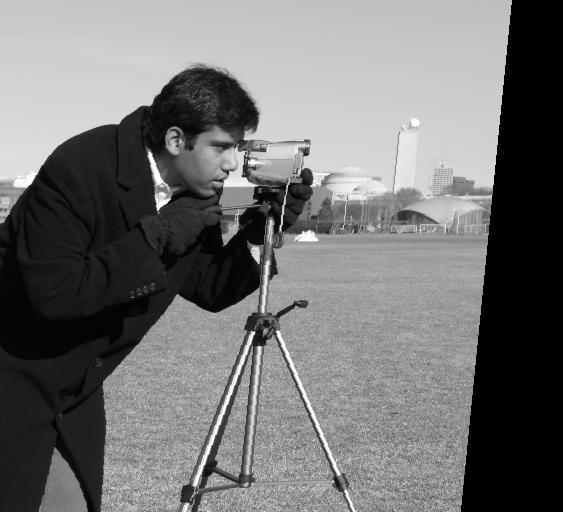

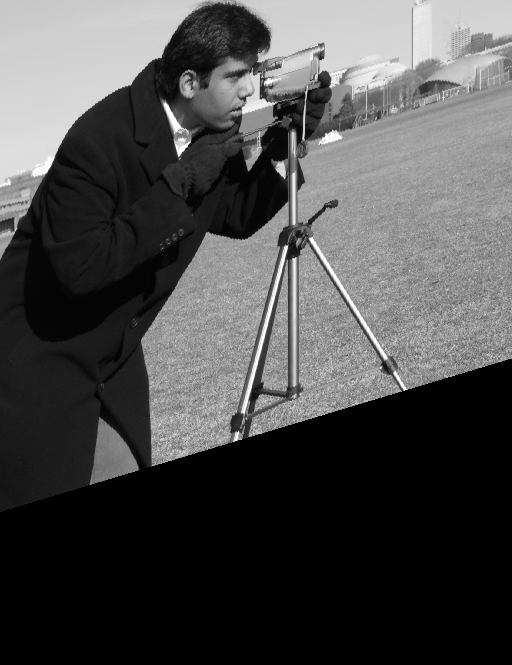

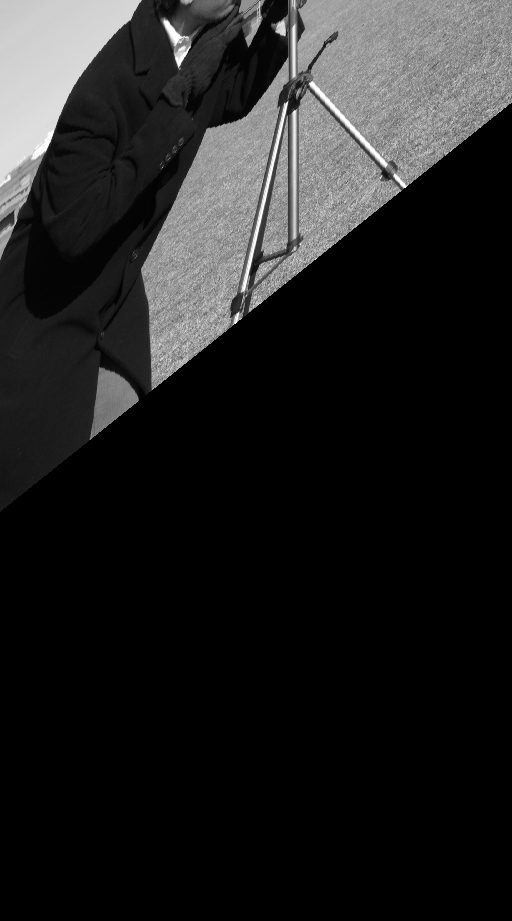

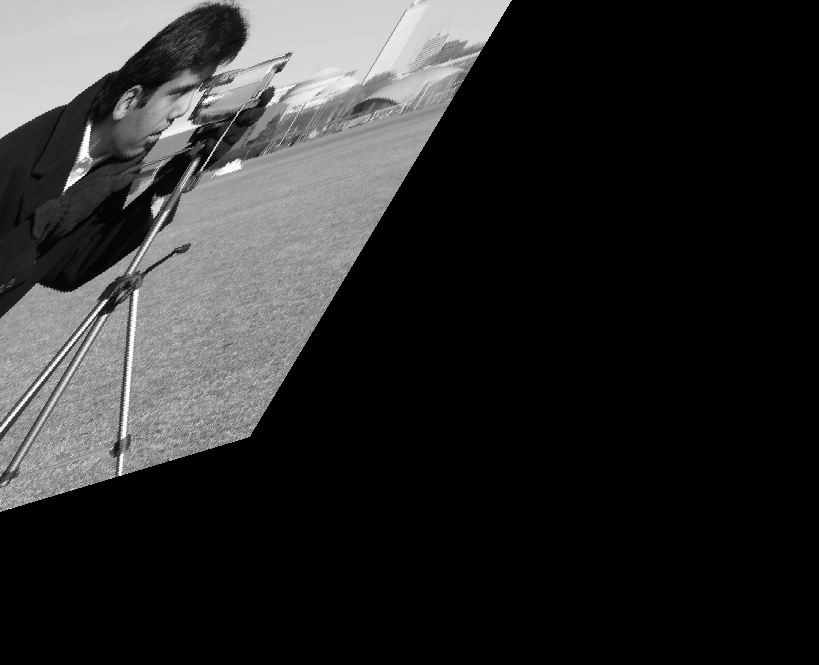

In [78]:
shear_x = 0.1
shear_y = 0
new_size = (int(width*shear_x + abs(height)), height)
sheared_img2 = img.transform(new_size, Image.Transform.AFFINE, (1, shear_x, 0, shear_y, 1, 0))
display(sheared_img2)

shear_x = 0
shear_y = 0.3
new_size = (width, int(height*shear_y + abs(width)))
sheared_img3 = img.transform(new_size, Image.Transform.AFFINE, (1, shear_x, 0, shear_y, 1, 0))
display(sheared_img3)

shear_x = 0
shear_y = 0.8
new_size = (width, int(height*shear_y + abs(width)))
sheared_img4 = img.transform(new_size, Image.Transform.AFFINE, (1, shear_x, 0, shear_y, 1, 0))
display(sheared_img4)

shear_x = 0.6
shear_y = 0.3
new_size = (int(width*shear_x + abs(height)), int(height*shear_y + abs(width)))
sheared_img5 = img.transform(new_size, Image.Transform.AFFINE, (1, shear_x, 0, shear_y, 1, 0))
display(sheared_img5)

#I should define a function rather than repeating the same code for different shear values, but for now, let's keep it simple 

# Intensity Transformations
Negative · Log · Power Law (Gamma)

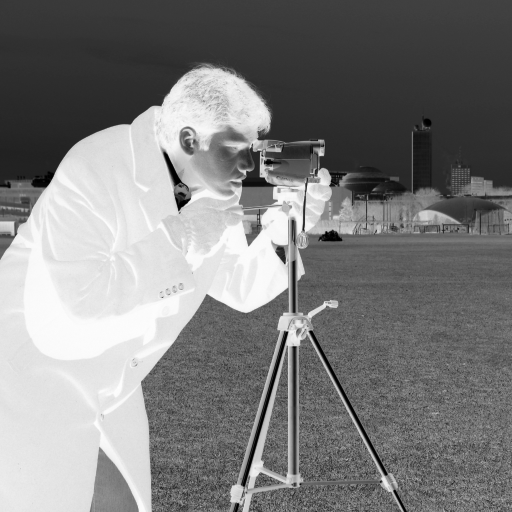

In [81]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation

img_array = np.array(img)
negative_array = 255 - img_array
negative_image1 = Image.fromarray(negative_array)
display(negative_image1)

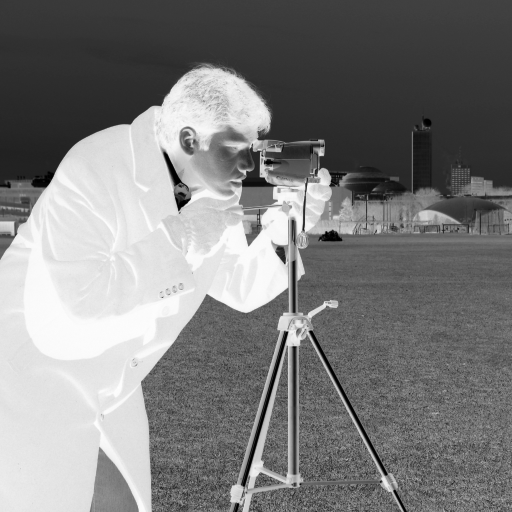

In [82]:
# Method 2: PIL's ImageOps
negative_img2 = ImageOps.invert(img)
display(negative_img2)

C:\Users\Microsoft\AppData\Local\Temp\ipykernel_21160\309273318.py:11: RuntimeWarning: divide by zero encountered in log
  log_array = c * np.log(1 + img_array)
C:\Users\Microsoft\AppData\Local\Temp\ipykernel_21160\309273318.py:12: RuntimeWarning: invalid value encountered in cast
  log_array = np.uint8(log_array)


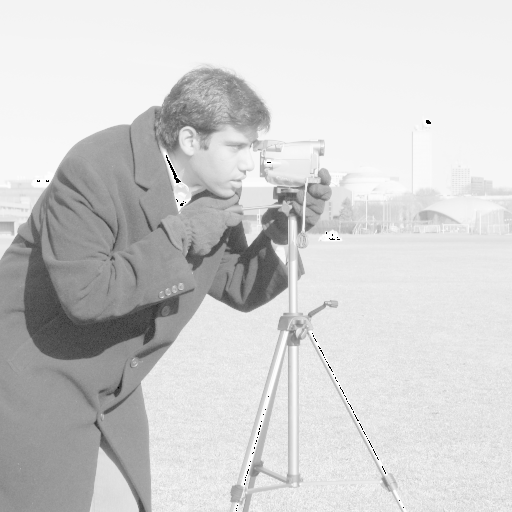

In [84]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
c = 255 / np.log(1 + 255)


# Apply the log transformation to each pixel
log_array = c * np.log(1 + img_array)
log_array = np.uint8(log_array)

log_img = Image.fromarray(log_array)
display(log_img)


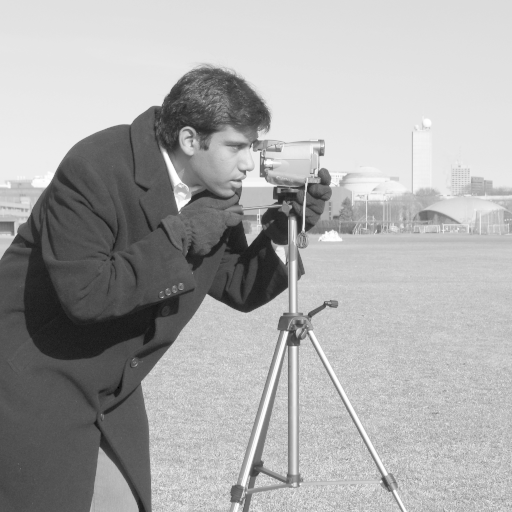

In [ ]:

# ── 3. Power-law / Gamma correction ───────────────
# s = c × r^γ
# 255 = c × 255^γ

gamma = 0.5

normalized = img_array / 255.0

gamma_array = 255 * (normalized ** gamma)

gamma_array = np.uint8(gamma_array)
gamma_img = Image.fromarray(gamma_array)
display(gamma_img)

Maryam Abu Qurain
2240002376